[!!!] Usar unrotate = True destruye la información sobre la posición del crop en la instancia de AnnotatedPage. Además, reduce la calidad de las imágenes por usar interpolación bicúbica, y esta misma interpolación introduce artefactos visuales en los bordes de la imagen. Úsese solamente en caso de revisión manual de las imágenes, y NO para el código de generación del dataset.
También invalida la forma en la que se generan los párrafos, la transcripción y los starting_indices.
-- -- Llevas un 12.89%
-- -- TAREA 126 -- ANOTACIÓN 0 --
-- -- --       Completada por: navarro                  
-- -- -- Último actualización: pambignacio8              con fecha de 2026-02-14 15:06:39.762991
-- -- -- -- -- -- -- -- ANOTACIÓN 0 -- -- PÁRRAFO 0
(126) - Párrafo 0/5, caja 0/17


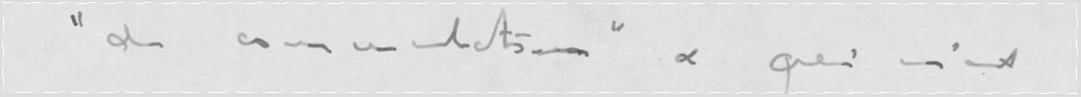

<IPython.core.display.Latex object>



(126) - Párrafo 0/5, caja 1/17


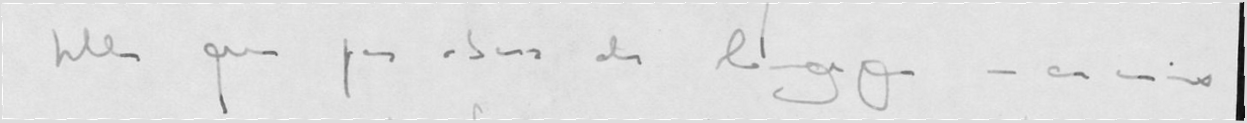

<IPython.core.display.Latex object>



(126) - Párrafo 0/5, caja 2/17


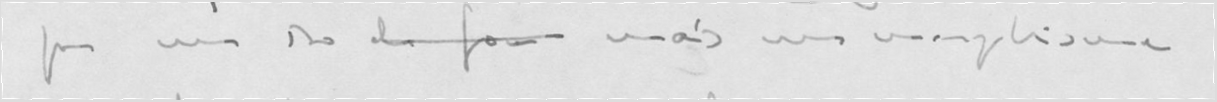

<IPython.core.display.Latex object>



(126) - Párrafo 0/5, caja 3/17


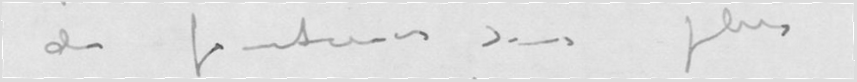

<IPython.core.display.Latex object>



(126) - Párrafo 0/5, caja 4/17


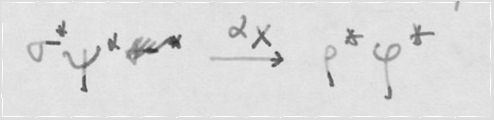

<IPython.core.display.Latex object>



(126) - Párrafo 0/5, caja 5/17


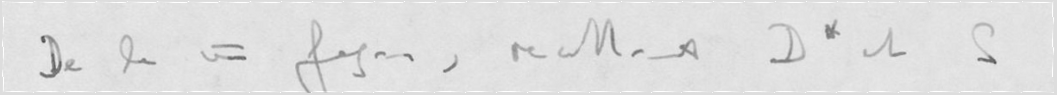

<IPython.core.display.Latex object>



(126) - Párrafo 0/5, caja 6/17


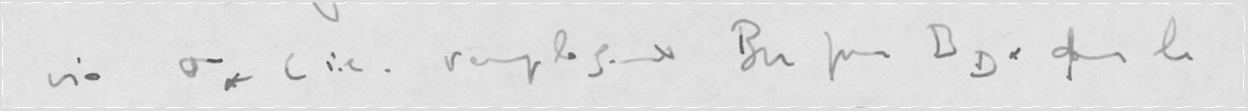

<IPython.core.display.Latex object>



(126) - Párrafo 0/5, caja 7/17


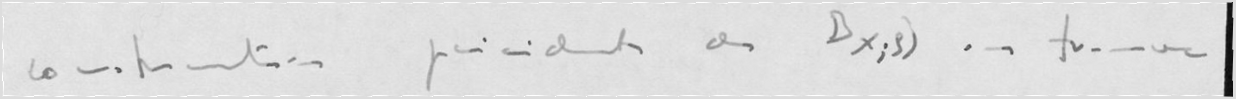

<IPython.core.display.Latex object>



(126) - Párrafo 0/5, caja 8/17


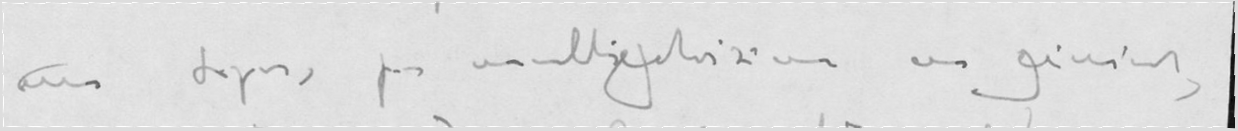

<IPython.core.display.Latex object>



(126) - Párrafo 0/5, caja 9/17


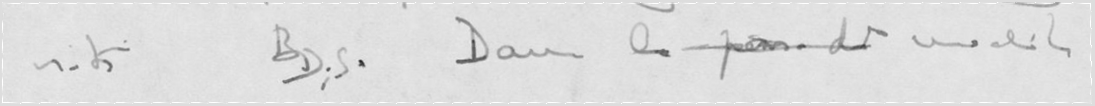

<IPython.core.display.Latex object>



(126) - Párrafo 0/5, caja 10/17


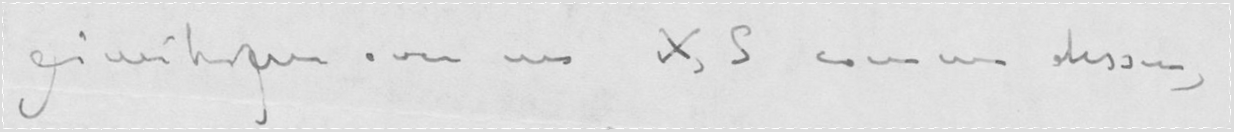

<IPython.core.display.Latex object>



(126) - Párrafo 0/5, caja 11/17


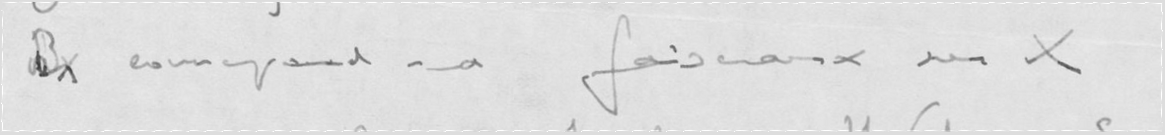

<IPython.core.display.Latex object>



(126) - Párrafo 0/5, caja 12/17


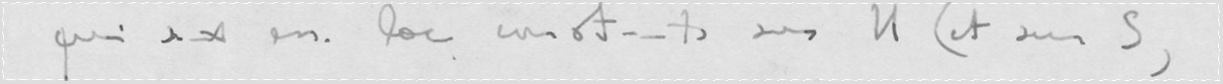

<IPython.core.display.Latex object>



(126) - Párrafo 0/5, caja 13/17


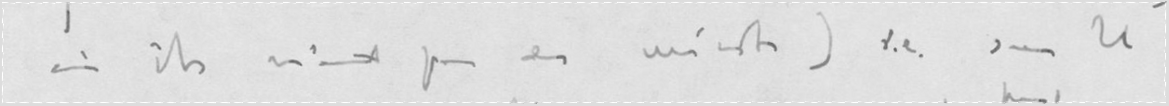

<IPython.core.display.Latex object>



(126) - Párrafo 0/5, caja 14/17


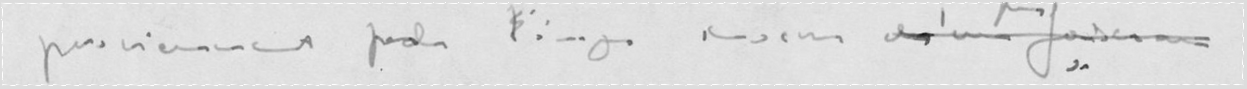

<IPython.core.display.Latex object>



(126) - Párrafo 0/5, caja 15/17


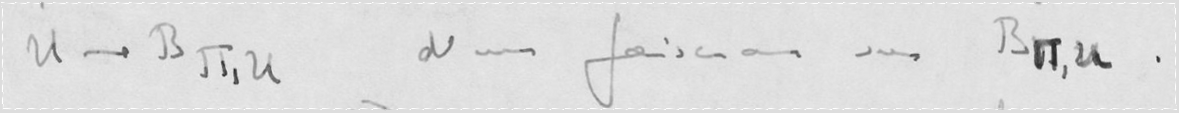

<IPython.core.display.Latex object>



(126) - Párrafo 0/5, caja 16/17


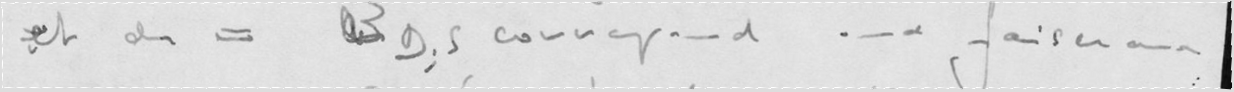

<IPython.core.display.Latex object>



-- -- -- -- -- -- -- -- ANOTACIÓN 0 -- -- PÁRRAFO 1
(126) - Párrafo 1/5, caja 0/3


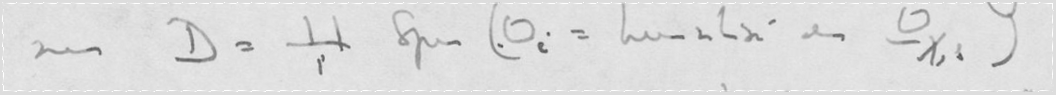

<IPython.core.display.Latex object>



(126) - Párrafo 1/5, caja 1/3


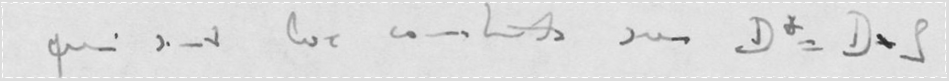

<IPython.core.display.Latex object>



(126) - Párrafo 1/5, caja 2/3


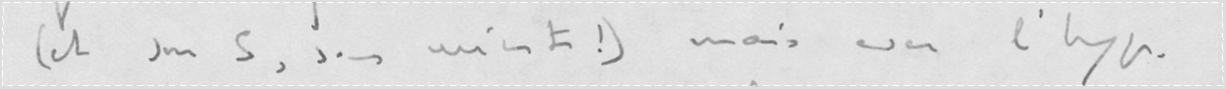

<IPython.core.display.Latex object>



-- -- -- -- -- -- -- -- ANOTACIÓN 0 -- -- PÁRRAFO 2
(126) - Párrafo 2/5, caja 0/1


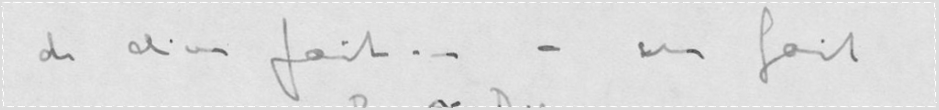

<IPython.core.display.Latex object>



-- -- -- -- -- -- -- -- ANOTACIÓN 0 -- -- PÁRRAFO 3
(126) - Párrafo 3/5, caja 0/1


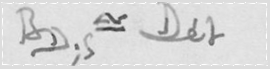

<IPython.core.display.Latex object>



-- -- -- -- -- -- -- -- ANOTACIÓN 0 -- -- PÁRRAFO 4
(126) - Párrafo 4/5, caja 0/1


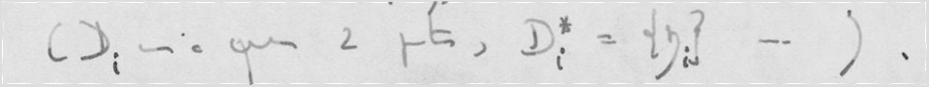

<IPython.core.display.Latex object>

KeyboardInterrupt: Interrupted by user

In [1]:
from IPython.display import Latex
from labelstudio.LabelStudioInterface import LabelStudioInterface
from IPython.display import clear_output
from preprocessing.helpers.helper_to_classes import get_image_path_from_task
from preprocessing.AnnotatedPage import AnnotatedPage
from PIL import Image

LS = LabelStudioInterface()
LS_export_data = LS.raw_tasks

#cajas revisadas hasta la 341.
max_revised = 125 #poner aquí la página por la que se está revisando.

INVERSE_ORDER = False

tasks = [task for task in sorted(LS_export_data, key = lambda task : task["id"]) if task["id"] > max_revised]

if INVERSE_ORDER:
    tasks = tasks[::-1]



for task in tasks:
    task_id = task["id"]

    img = Image.open(get_image_path_from_task(task))


    for (k,ann) in enumerate(task["annotations"]):
        Ann = AnnotatedPage(ann, img, unrotate = True)
        print(f"-- -- Llevas un {len([x for x in LS.raw_tasks if x["id"] <= task_id]) / len(LS_export_data) * 100:.2f}%")
        print(f"-- -- TAREA {task_id} -- ANOTACIÓN {k} --")
        print(f"-- -- --       Completada por: {Ann.completer:<25}")
        print(f"-- -- -- Último actualización: {Ann.updater:<25} con fecha de {Ann.last_update_time}")


        for (par_index, paragraph) in enumerate(Ann.paragraphs):
            print(f"-- -- -- -- -- -- -- -- ANOTACIÓN {k} -- -- PÁRRAFO {par_index}")
            for (box_index, box) in enumerate(paragraph.image_boxes):
                print(f"({task_id}) - Párrafo {par_index}/{len(Ann.paragraphs)}, caja {box_index}/{len(paragraph.image_boxes)}")
                display(Ann.generate_collage([box.id]))
                display(Latex(box.fragment.text))
                print("\n")

        a = input("Continuamos? (vacío para continuar)")
        if a.lower() != "":
            raise KeyboardInterrupt("Se ha parado el proceso")

        clear_output(wait = True)